## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set plot style
sns.set_theme(style="whitegrid")


## Downloading dataset

In [2]:
import kagglehub
import os

# 1. Download
path = kagglehub.dataset_download("loveall/appliances-energy-prediction")
print("Path to dataset folder:", path)

# 2. Automatically find the CSV file inside that folder
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
full_csv_path = os.path.join(path, csv_file)

print(f"Loading file: {csv_file}")

# 3. Load into Pandas DataFrame
df = pd.read_csv(full_csv_path)

# Display shape and first few rows
print(f"Dataset Shape: {df.shape}")
df.head()

100%|██████████| 1.71M/1.71M [00:00<00:00, 2.26MB/s]

Extracting files...


Path to dataset folder: /root/.cache/kagglehub/datasets/loveall/appliances-energy-prediction/versions/1
Loading file: KAG_energydata_complete.csv
Dataset Shape: (19735, 29)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


## Feature Engineering & Class Creation

In [15]:
# 1. Convert date column to datetime object
df['date'] = pd.to_datetime(df['date'])

# 2. Advanced Time Features
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
df['month'] = df['date'].dt.month

# 3. Smart Home Domain Features (Temperature Differences)
# Large differences between inside and outside usually mean heating/cooling is running
df['Temp_Diff_LivingRoom'] = df['T2'] - df['T_out']
df['Temp_Diff_Kitchen'] = df['T1'] - df['T_out']

# 4. Define the Target (High vs Low)
median_energy = df['Appliances'].median()
df['Energy_Consumption_Class'] = np.where(df['Appliances'] > median_energy, 1, 0)

# Drop non-feature columns
X = df.drop(columns=['date', 'Appliances', 'Energy_Consumption_Class'])
y = df['Energy_Consumption_Class']

print("Enhanced features created successfully!")

Enhanced features created successfully!


## Train-Test Split

In [6]:
# 80% train, 20% test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Decision Tree Classifier

In [16]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to test
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 8, 10, 12, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize a base Decision Tree
base_dt = DecisionTreeClassifier(random_state=42)

# Initialize Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=base_dt, param_grid=param_grid,
                           cv=5, n_jobs=-1, scoring='accuracy', verbose=1)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Extract the best model
best_dt_model = grid_search.best_estimator_

print("\nBest Parameters Found:")
print(grid_search.best_params_)

Fitting 5 folds for each of 90 candidates, totalling 450 fits

Best Parameters Found:
{'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}


## Making Prediction

In [17]:
# Make predictions with the tuned model
y_pred = best_dt_model.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Optimized Model Accuracy: {accuracy:.2f}\n")


Optimized Model Accuracy: 0.87



###### without gridsearchcv 78 with 87.. hugeee differenece observed !!!

In [19]:
# Detailed Classification Report
print("Updated Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Low Consumption', 'High Consumption']))

Updated Classification Report:
                  precision    recall  f1-score   support

 Low Consumption       0.87      0.89      0.88      2127
High Consumption       0.87      0.85      0.86      1820

        accuracy                           0.87      3947
       macro avg       0.87      0.87      0.87      3947
    weighted avg       0.87      0.87      0.87      3947



## Visualizations

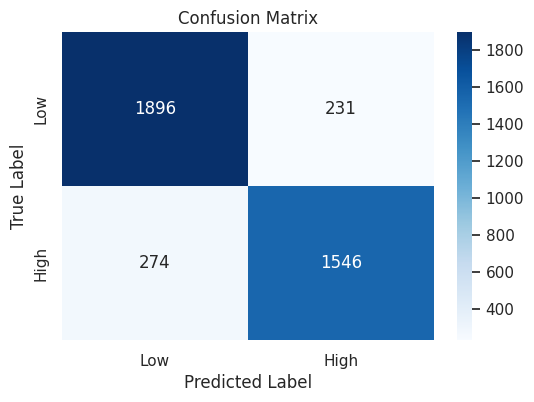

In [20]:
# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

/tmp/ipykernel_12455/3625597748.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices][:10], y=X.columns[indices][:10], palette='viridis')


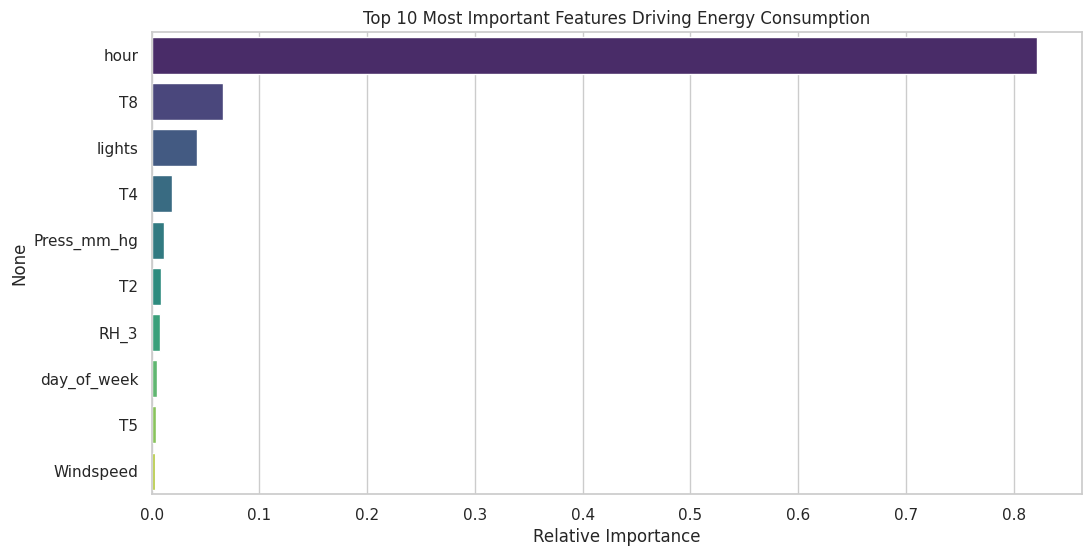

In [21]:
# Plot Feature Importances
importances = dt_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices][:10], y=X.columns[indices][:10], palette='viridis')
plt.title('Top 10 Most Important Features Driving Energy Consumption')
plt.xlabel('Relative Importance')
plt.show()


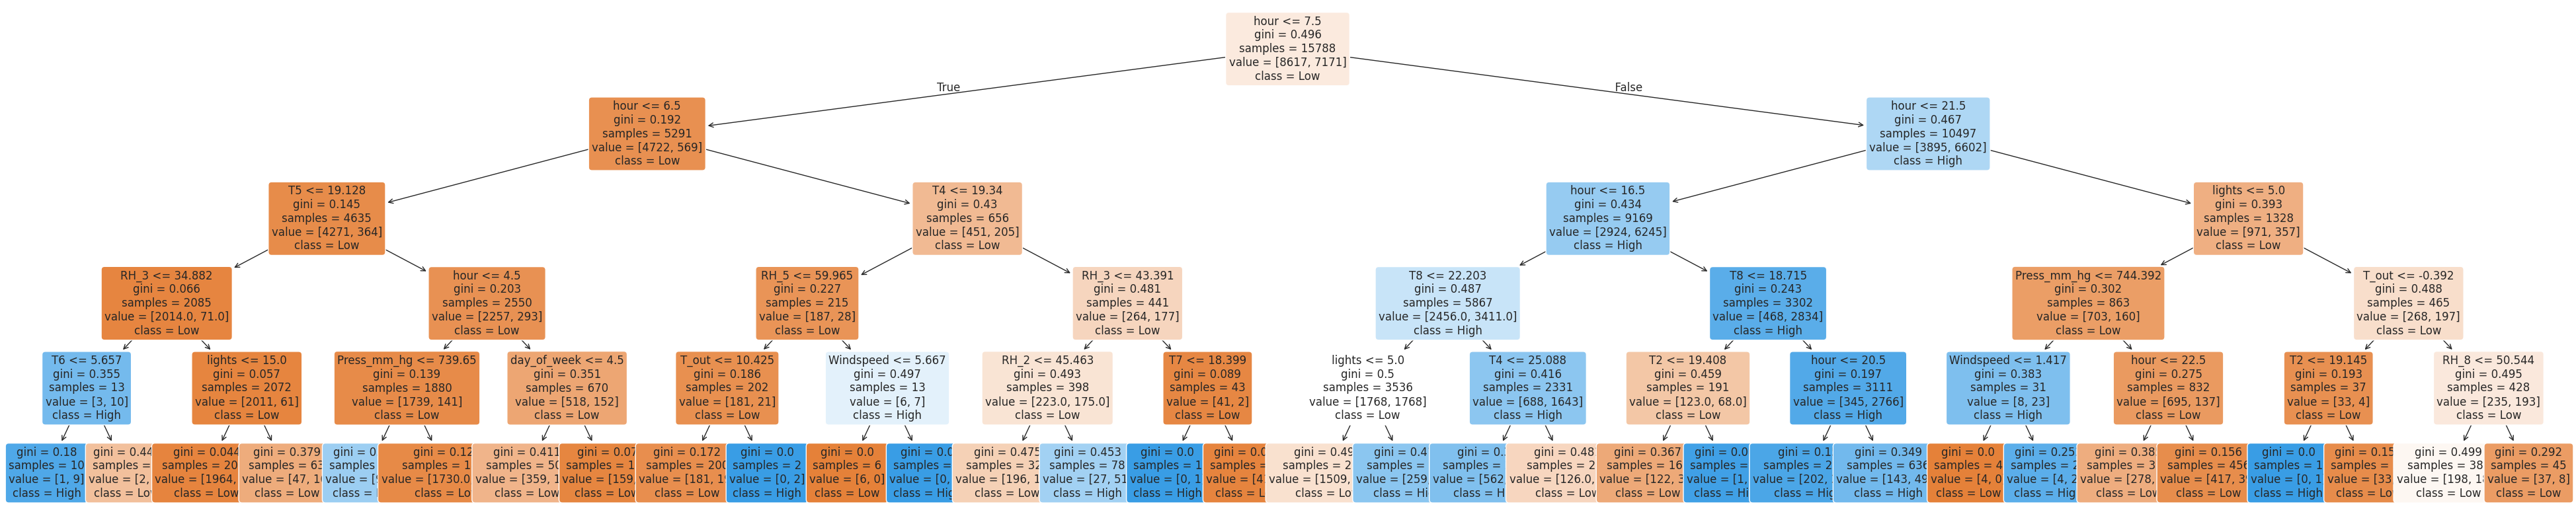

In [32]:

# Visualize a slice of the actual Decision Tree
plt.figure(figsize=(50, 10))
plot_tree(dt_model, feature_names=X.columns,
          class_names=['Low', 'High'], filled=True, rounded=True, fontsize=12)
plt.show()

## Advanced Feature – Smart Recommendation Engine

In [23]:
def generate_smart_suggestion(row_data, predicted_class):
    if predicted_class == 0:
        return "Your energy consumption is optimal right now. Keep it up!"

    suggestions = []

    # Check Time of Day (Peak hours usually 5 PM - 10 PM)
    if 17 <= row_data['hour'] <= 22:
        suggestions.append("Peak hours detected! Consider postponing heavy laundry or washing machine cycles until after 10 PM.")

    # Check if lights are contributing heavily
    if row_data['lights'] > 20:
        suggestions.append(" High lighting usage noticed. Turn off unneeded room lights or switch to dim settings.")

    # Check Temperature delta (Indoor vs Outdoor proxy logic)
    if row_data['T2'] > 22 and row_data['To'] > 21:
        suggestions.append(" The outdoor temperature is comfortable. Try opening windows instead of turning on the AC.")

    if not suggestions:
        suggestions.append(" High energy consumption predicted. Review and turn off idle electronics.")

    return " \n".join(suggestions)

# Let's test it out on a random high-consumption row from our test set
high_energy_sample = X_test[y_pred == 1].iloc[0]
sample_prediction = 1

print("--- Simulated Smart Home Alert ---")
print(generate_smart_suggestion(high_energy_sample, sample_prediction))

--- Simulated Smart Home Alert ---
Peak hours detected! Consider postponing heavy laundry or washing machine cycles until after 10 PM.
